# Brouillon 6 : agir sur le monde (intervention, expérience aléatoire, instrument)

Trois questions :
1. Si on **prend une décision** à partir d'un modèle prédictif, que se passe-t-il vraiment ?
2. Pourquoi une **expérience aléatoire** (A/B test) règle le problème ?
3. Si la température n'est **pas observée**, peut-on quand même retrouver l'effet ? (variable instrumentale)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import doubleml as dml

## 1. Une décision prise avec un modèle prédictif
Scénario : une mairie veut réduire les noyades. Elle a entraîné un Gradient Boosting sur noyades ~ glaces
(il prédit bien, R² ≈ 0.78). Elle envisage une taxe qui **divise par deux** les ventes de glaces et demande au
modèle combien de noyades on évitera.

Pour connaître la vérité, il faut simuler le monde *après* la taxe : même température, mêmes aléas, mais glaces
divisées par deux. Je fais ça en ajoutant un facteur sur les glaces dans la simulation (même seed = mêmes tirages).

In [2]:
def simuler(n=5000, effet=0.0, seed=123, facteur_glaces=1.0):
    rng = np.random.default_rng(seed)
    temperature = rng.normal(20, 6, n)
    glaces = facteur_glaces * (2 * temperature + 0.05 * temperature**2 + rng.normal(0, 5, n))
    noyades = 0.3 * temperature + 0.01 * temperature**2 + effet * glaces + rng.normal(0, 2, n)
    return pd.DataFrame({"temperature": temperature, "glaces": glaces, "noyades": noyades})

avant = simuler()
apres = simuler(facteur_glaces=0.5)
print("température identique :", np.allclose(avant.temperature, apres.temperature))
print("noyades moyennes avant / après (effet vrai = 0) :", avant.noyades.mean().round(3), apres.noyades.mean().round(3))

température identique : True
noyades moyennes avant / après (effet vrai = 0) : 10.404 10.404


Comme l'effet vrai est nul, la taxe ne change rien aux noyades. Que prédit le modèle ?

In [3]:
gb = GradientBoostingRegressor(random_state=0).fit(avant[["glaces"]], avant.noyades)
pred_avant = gb.predict(avant[["glaces"]]).mean()
pred_apres = gb.predict(avant[["glaces"]] * 0.5).mean()
print("prédiction moyenne avant :", round(pred_avant, 3))
print("prédiction moyenne si glaces / 2 :", round(pred_apres, 3))
print("baisse prédite (%) :", round(100 * (pred_apres - pred_avant) / pred_avant, 1))

prédiction moyenne avant : 10.404
prédiction moyenne si glaces / 2 : 5.28
baisse prédite (%) : -49.2


Le modèle annonce une forte baisse des noyades, alors qu'en réalité il n'y en a aucune.
Il répond à « combien de noyades les jours où l'on vend peu de glaces ? » (des jours froids),
pas à « combien si on force les ventes à baisser ? ».

Et avec un effet vrai de 0.5 ? Là, la taxe a vraiment un effet.

In [4]:
def scenario(effet, facteur=0.5):
    avant = simuler(effet=effet)
    apres = simuler(effet=effet, facteur_glaces=facteur)
    gb = GradientBoostingRegressor(random_state=0).fit(avant[["glaces"]], avant.noyades)
    X_apres = avant[["glaces"]] * facteur
    # Double ML : effet estimé × variation moyenne des glaces
    donnees = dml.DoubleMLData(avant, y_col="noyades", d_cols="glaces", x_cols=["temperature"])
    rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=0, n_jobs=-1)
    np.random.seed(0)
    m = dml.DoubleMLPLR(donnees, rf, rf, n_folds=5).fit()
    return {
        "effet vrai": effet,
        "noyades observées": avant.noyades.mean(),
        "réalité après taxe": apres.noyades.mean(),
        "prédit par le GB": gb.predict(X_apres).mean(),
        "prédit avec le Double ML": avant.noyades.mean() + m.coef[0] * (X_apres.glaces - avant.glaces).mean(),
    }

pd.DataFrame([scenario(0.0), scenario(0.5)]).round(2)

,effet vrai,noyades observées,réalité après taxe,prédit par le GB,prédit avec le Double ML
0,0.0,10.4,10.4,5.28,10.29
1,0.5,41.4,25.9,20.77,25.90


Avec effet = 0.5, le GB surestime la baisse (il ajoute l'effet de « jours plus froids »). Le Double ML, qui estime
l'effet causal, donne la bonne prévision dans les deux mondes.

Remarque : réutiliser le même objet `rf` pour ml_l et ml_m marche (DoubleML clone les modèles), mais dans `src/`
je garderai deux objets séparés, c'est plus lisible.

## 2. L'expérience aléatoire
On distribue les glaces **au hasard** (par exemple des glaces gratuites tirées au sort), sans lien avec la
température. Même moyenne et même écart-type que les ventes observées.

In [5]:
def simuler_experience(n=5000, effet=0.0, seed=321):
    rng = np.random.default_rng(seed)
    temperature = rng.normal(20, 6, n)
    glaces = rng.normal(62, 25, n)  # tirées au sort, indépendantes de la température
    noyades = 0.3 * temperature + 0.01 * temperature**2 + effet * glaces + rng.normal(0, 2, n)
    return pd.DataFrame({"temperature": temperature, "glaces": glaces, "noyades": noyades})

exp0 = simuler_experience()
print("corrélation température-glaces :", round(exp0.temperature.corr(exp0.glaces), 3))

corrélation température-glaces : 0.002


In [6]:
def ols(df, variables):
    m = sm.OLS(df.noyades, sm.add_constant(df[variables])).fit()
    return m.params["glaces"], *m.conf_int().loc["glaces"].tolist()

for effet in [0.0, 0.5]:
    e = simuler_experience(effet=effet)
    e["temperature2"] = e.temperature**2
    print(f"effet vrai {effet} | OLS naïf : {np.round(ols(e, ['glaces']), 4)}"
          f" | OLS + T + T² : {np.round(ols(e, ['glaces', 'temperature', 'temperature2']), 4)}")

effet vrai 0.0 | OLS naïf : [ 0.0013 -0.0038  0.0065] | OLS + T + T² : [ 0.001  -0.0012  0.0032]
effet vrai 0.5 | OLS naïf : [0.5013 0.4962 0.5065] | OLS + T + T² : [0.501  0.4988 0.5032]


Dans l'expérience, la régression **naïve** retrouve le vrai effet : la température n'est plus un confondeur
puisque les glaces ne dépendent plus d'elle. Contrôler la température reste utile, mais seulement pour la
**précision** (IC plus étroit), plus pour le biais.

Et le GB naïf ?

In [7]:
gb_exp = GradientBoostingRegressor(random_state=0).fit(exp0[["glaces"]], exp0.noyades)
X1 = exp0[["glaces"]] + 1
print("effet implicite du GB dans l'expérience :", round(np.mean(gb_exp.predict(X1) - gb_exp.predict(exp0[["glaces"]])), 4))

effet implicite du GB dans l'expérience : 0.0229


Petit (environ 0.02), bien loin des 0.17 du cas observationnel. Le même algorithme, sur des données expérimentales, donne la bonne réponse : encore une fois,
ce sont les données (et la question) qui comptent, pas l'algorithme.

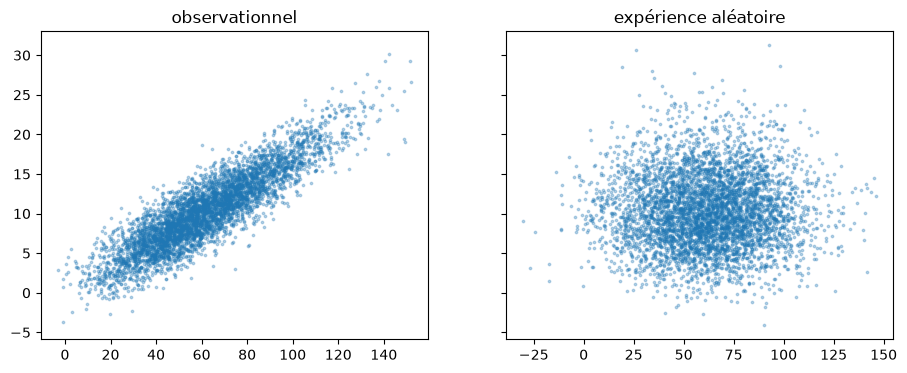

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
obs = simuler()
axes[0].scatter(obs.glaces, obs.noyades, s=3, alpha=0.3)
axes[0].set_title("observationnel")
axes[1].scatter(exp0.glaces, exp0.noyades, s=3, alpha=0.3)
axes[1].set_title("expérience aléatoire")
plt.show()

## 3. Variable instrumentale (température non observée)
Un instrument Z doit :
- influencer les glaces (**pertinence**) ;
- n'influencer les noyades **que** via les glaces (**exclusion**) ;
- être indépendant du confondeur.

Exemple : une **grève des livreurs** de glaces, certains jours tirés au hasard (20 % des jours), qui fait chuter
les ventes de 20 unités.

In [9]:
def simuler_instrument(n=5000, effet=0.0, seed=777, effet_greve_glaces=-20.0, effet_greve_noyades=0.0):
    rng = np.random.default_rng(seed)
    temperature = rng.normal(20, 6, n)
    greve = rng.binomial(1, 0.2, n)
    glaces = 2 * temperature + 0.05 * temperature**2 + effet_greve_glaces * greve + rng.normal(0, 5, n)
    noyades = (0.3 * temperature + 0.01 * temperature**2 + effet * glaces
               + effet_greve_noyades * greve + rng.normal(0, 2, n))
    return pd.DataFrame({"temperature": temperature, "greve": greve, "glaces": glaces, "noyades": noyades})

iv0 = simuler_instrument()
iv0[["greve", "glaces", "noyades", "temperature"]].corr().round(3)

,greve,glaces,noyades,temperature
greve,1.000,-0.290,0.019,0.020
glaces,-0.290,1.000,0.844,0.926
noyades,0.019,0.844,1.000,0.900
temperature,0.020,0.926,0.900,1.000


Estimateur de Wald à la main : effet = cov(noyades, grève) / cov(glaces, grève).

In [10]:
cov = iv0[["greve", "glaces", "noyades"]].cov()
print("Wald :", round(cov.loc["noyades", "greve"] / cov.loc["glaces", "greve"], 4))
print("OLS naïf :", np.round(ols(iv0, ["glaces"]), 4))

Wald : -0.0119
OLS naïf : [0.1536 0.1509 0.1563]


Pour avoir un IC correct, j'utilise les doubles moindres carrés (2SLS). Statsmodels en a une version dans
`statsmodels.sandbox` ; je vérifie qu'elle existe dans la version installée.

In [11]:
from statsmodels.sandbox.regression.gmm import IV2SLS

def iv_2sls(df):
    y = df.noyades
    X = sm.add_constant(df[["glaces"]])
    Z = sm.add_constant(df[["greve"]])
    res = IV2SLS(y, X, instrument=Z).fit()
    return res.params["glaces"], *res.conf_int().loc["glaces"].tolist()

print(np.round(iv_2sls(iv0), 4))

[-0.0119 -0.0302  0.0065]


Même valeur que Wald (normal avec un seul instrument), et un IC qui contient 0.
Vérification à la main de l'écart-type : 2SLS « manuel » en deux étapes donnerait un mauvais écart-type
(les résidus de la 2e étape ne sont pas les bons). Je compare :

In [12]:
etape1 = sm.OLS(iv0.glaces, sm.add_constant(iv0[["greve"]])).fit()
glaces_hat = etape1.fittedvalues
etape2 = sm.OLS(iv0.noyades, sm.add_constant(glaces_hat.rename("glaces"))).fit()
print("coef manuel :", round(etape2.params["glaces"], 4), " se manuel :", round(etape2.bse["glaces"], 4))
res_iv = IV2SLS(iv0.noyades, sm.add_constant(iv0[["glaces"]]), instrument=sm.add_constant(iv0[["greve"]])).fit()
print("coef IV2SLS :", round(res_iv.params["glaces"], 4), " se IV2SLS :", round(res_iv.bse["glaces"], 4))

coef manuel : -0.0119  se manuel : 0.0089
coef IV2SLS : -0.0119  se IV2SLS : 0.0094


Même coefficient, écart-type différent : il faut bien utiliser IV2SLS (ou corriger à la main). Je garde IV2SLS.

### Effet vrai = 0.5

In [13]:
print(np.round(iv_2sls(simuler_instrument(effet=0.5)), 4), np.round(ols(simuler_instrument(effet=0.5), ["glaces"]), 4))

[0.4881 0.4698 0.5065] [0.6536 0.6509 0.6563]


### Les pièges de l'instrument
**Instrument faible** : la grève ne fait baisser les ventes que de 2 unités.

In [14]:
faible = simuler_instrument(effet_greve_glaces=-2.0)
print("1re étape F :", round(sm.OLS(faible.glaces, sm.add_constant(faible[["greve"]])).fit().fvalue, 1))
print("IV faible :", np.round(iv_2sls(faible), 4))
print("1re étape F (bon instrument) :", round(sm.OLS(iv0.glaces, sm.add_constant(iv0[["greve"]])).fit().fvalue, 1))

1re étape F : 0.6
IV faible : [-0.3159 -1.5142  0.8823]
1re étape F (bon instrument) : 459.2


F de première étape = 0.6 (règle usuelle : il faut F > 10) et IC de [-1.5 ; 0.9] : l'estimation ne dit plus rien.

**Instrument invalide** : la grève touche aussi les maîtres-nageurs (moins de surveillance → +1 noyade par jour de grève).
L'exclusion est violée.

In [15]:
invalide = simuler_instrument(effet_greve_noyades=1.0)
print("IV invalide :", np.round(iv_2sls(invalide), 4))

IV invalide : [-0.0653 -0.0882 -0.0425]


Estimation d'environ -0.065, avec un IC qui exclut 0 : on conclurait que les glaces **réduisent** les noyades,
avec un résultat qui a l'air tout à fait sérieux. Comme pour le collider, rien dans les données ne
signale le problème : l'hypothèse d'exclusion ne se teste pas, elle se justifie.

Est-ce que le résultat de l'instrument faible dépend beaucoup de la seed ? Petit Monte Carlo (200 tirages) :

In [16]:
estim = [iv_2sls(simuler_instrument(effet_greve_glaces=-2.0, seed=s))[0] for s in range(200)]
print("médiane :", round(np.median(estim), 3), " quantiles 5 % / 95 % :", np.round(np.quantile(estim, [0.05, 0.95]), 2))

médiane : 0.009  quantiles 5 % / 95 % : [-0.25  0.09]


Avec un instrument faible, la médiane reste proche de 0, mais 90 % des estimations sont entre -0.25 et 0.09 :
une estimation isolée peut tomber à peu près n'importe où. Avec le bon instrument, l'IC fait ± 0.02.

## Bilan pour `src/`
- `simulation.py` : argument `facteur_glaces` dans `simuler_glaces_noyades` (défaut 1, ne change rien
  aux résultats précédents), `simuler_experience_aleatoire`, `simuler_instrument`.
- `analyse.py` : `prevoir_intervention(df_avant, df_apres, facteur)`, `tableau_experience`,
  `effet_iv` (IV2SLS) et `tableau_instrument` (OLS naïf, bon instrument, faible, invalide).
- `graphiques.py` : barres « prédit vs réalité », nuages observationnel vs expérience, DAG de l'instrument,
  estimations IV (réutiliser `figure_estimations`).